# 0. Introduction to Neural Networks



Today, we often talk about LLMs (large language models) like ChatGPT and DeepSeek when discussing deep learning. However, these models represent only the latest chapter in a much longer story that stretches back to the 1950s. Modern breakthroughs in GenAI are built upon decades of mathematical development. In these notebooks, we begin with the perceptron and progressively build toward the multilayer perceptron (MLP); arguably the first true artificial neural network (ANN). Let us import the dependencies for this notebook,

In [1]:
# Importing,
import matplotlib.pyplot as plt
import numpy as np

### 0.1. Perceptrons

The building blocks of early ANNs known as feed-foward neural networks and a key component of modern transformer-based architectures like LLM is the **perceptron**. Perceptrons are also called _artificial neurons_ and are inspired from biological neurons. However, they are not meant to replicate biological ones in detail. Instead, they offer a simplified way to process information and make predictions. Compared to classical ML, perceptrons are most closely related to linear classifiers. Mathematically, a single perceptron is written as,

$$
a = \phi (w_1 x_1 + w_2 x_2 + ... + w_d x_d + b)
$$

We immediately notice that a perceptron is simiiar to a linear classifier model $z = w_1 x_1 + w_2 x_2 + ... + w_d x_d + b$ fed into an **activation function** $\phi$. Our input features are stored in a column vector $\mathbf{x} = (x_1, x_2, ..., x_d)$ with each feature having an associated weight contained within $\mathbf{w} = (w_1, w_2, ..., w_d)$. $a$ denotes the output of the neuron, $b$ is its bias and $d$ is the number of input features to the neuron. We may conveniently write the neuron as, 

$$
a = \phi (\mathbf{x}^T \mathbf{w}  + b)
$$

Schematically,

[Diagram]

### 0.2. The Anatomy of MLPs

The real power of the perceptron emerges when we arrange many of them in parallel to form a layer. By stacking such layers sequentially, we construct a multi-layer perceptron (MLP). Unlike a single perceptron, which can only learn linear decision boundaries, an MLP introduces nonlinearity through activation functions between layers. This enables the network to model complex, non-linearly separable patterns.

[Diagram]

0.4. Gradient Descent & Back Propagation

Artificial neural networks such as MLPs are parametric models with each layer containing a finite number of trainable parameters (weights and biases). Training a neural network involves minimising an loss function $\mathcal{L}(y, \hat{y}(\Theta))$ (more generally a objective function $J$) with respect to the model parameters $\Theta$. The loss function attempts to quantify the discrepancy between the desired target $y_i$ and the model prediction $\hat{y}_i$ across all samples. Gradient descent is overwhelming the most popular way of solving this optimisation problem. In its most basic form,

$$
\Theta_{t+1} = \Theta_t - \alpha \nabla_{\Theta}f(\Theta)
$$

where the trainable parameters of the model $\Theta$ are updated every iteration by the gradient $\nabla_{\Theta}f(\Theta)$. The **learning rate** $\alpha << 1$ controls the size of the adjustment and is a model hyperparameter. 

### 0.3. Universal Approximators

Neural networks are often referred to as universal function approximators. This is because neural networks can, in principle, approximate any continuous function to any desired degree of accuracy (given it has a certain structure). In 1989, George Cybenko showed that we can always approximate arbitrary continous functions with feed-forward neural networks that only have a single hidden layer and sigmoid-like activation functions. Others would go to show that any nonpolynomial activation function in MLPs lead to the universal approximation property. These theorems in the foundations of theoretical machine learning provide the mathematical justification for using neural networks to model the complex, non-linear relationships often found in real-world data.

### 0.4. Activation Functions

Without activation functions $\phi$, neural networks would not be able to act as universal function approximators. One of the most common activation functions, arguably the canonical one for historical reasons, is the sigmoid or logistic function $\sigma$. It has the form,

$$
\sigma(z) = \frac{1}{1+e^{-z}}
$$

Graphing $\sigma(z)$ gives,

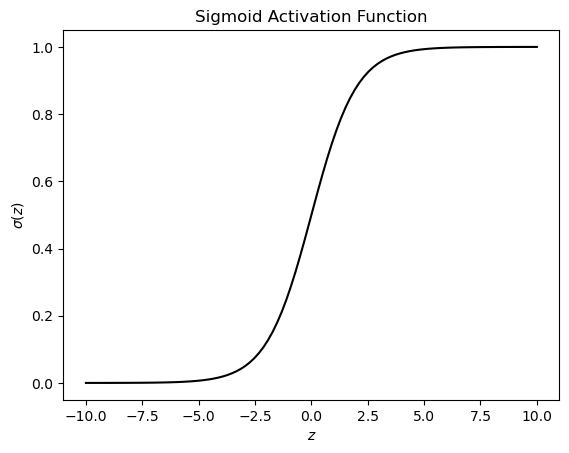

In [13]:
def sigmoid(z):
    """The sigmoid activation function."""
    return 1.0/(1.0 + np.exp(-z))

# Plotting,
z_vals = np.linspace(start=-10, stop=10, num=100)
plt.plot(z_vals, sigmoid(z_vals), color="black")
plt.title("Sigmoid Activation Function")
plt.xlabel("$z$")
plt.ylabel(r"$\sigma(z)$")
plt.show()

The sigmoid function has a characteristic _S_ shape where it maps input any real values $z$ to real numbers between $0$ and $1$. More precisely $\sigma \in [0, 1]$. In the context of a neuron, the sigmoid activation function can be thought of as probabilistic ON-OFF switch. When $z$ is small, we have a low activation where $\sigma(z) \approx 0$ and a high activation $\sigma(z) \approx 1$ when $z$ is large. Similarities between this and biological neurons can be drawn. A biological neuron integrates incoming electrical signals from many other neurons. If the combined input exceeds a certain threshold, the neuron generates an action potential and fires; if not, it remains inactive. However, this analogy should not be taken too literally. A key property of a sigmoid function is that it is differentiable with its derivative computed via $\sigma(z)' = \sigma(z) (1 - \sigma(z))$. 

Another common activation function, the most used in modern DL, is the ReLU (rectified linear unit) activation function $\text{ReLU}(z)$,

$$
\mathrm{ReLU}(z) =
\begin{cases}
0 & \text{if } z < 0 \\
z & \text{if } z \ge 0
\end{cases}
$$

For negative values, $z<0$, the function returns zero. When $z \geq 0$, $z$ is returned as the output. Compared to the sigmoid function $\sigma(z)$, the ReLU activiation function allows for faster foward-pass and backprogation compute times. It is highly valued for its simplicity and efficiency. ReLU activiation functions are often the default chose for hidden layers of many ANNs as they introduce non-linearity while minimal computational cost. Visualising the ReLU function,

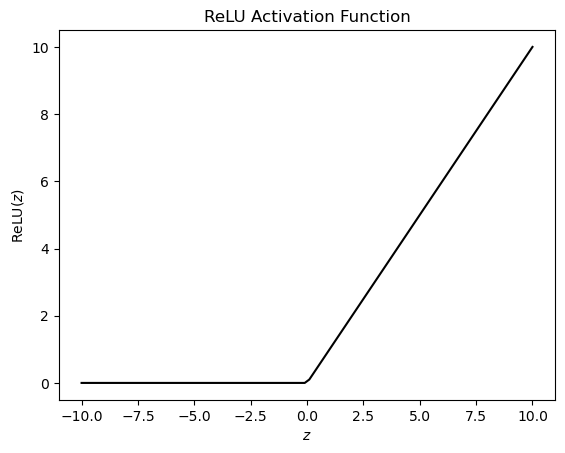

In [15]:
def sigmoid(z):
    """The ReLU (rectified linear unit) activation function."""
    return np.maximum(0, z)

# Plotting,
z_vals = np.linspace(start=-10, stop=10, num=100)
plt.plot(z_vals, sigmoid(z_vals), color="black")
plt.title("ReLU Activation Function")
plt.xlabel("$z$")
plt.ylabel(r"$\text{ReLU}(z)$")
plt.show()

### 0.5. Glossary 

We have introduced many terms of which are sometimes used interchangably. However, we should clarify the meaning of each term in detail.

| Abbreviation | Technical Meaning |
|--------------|-----------------|
| ANN          | Artificial Neural Network – a computational model inspired by biological neural networks, encompassing all types of neural networks. The most general term for deep-learning models.|
| FNN          | Feedforward Neural Network – a class of ANNs where information flows strictly from input to output without cycles; can have 0 or more hidden layers. |
| MLP          | Multilayer Perceptron – a fully connected feedforward neural network with at least one hidden layer and nonlinear activations. |
| DNN          | Deep Neural Network – a neural network with multiple hidden layers (can be MLPs, CNNs, etc.). |

### References